In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

import pyfield
import pyfield.transducers as transducers
from pyfield.psimulation import PyField

from pyfield.utilities.matlab import mat_struct_to_dict, explore_mat



%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Settings:

# 1. Import .mat and .npz


In [71]:
def MSE(a, b):
    return np.square(np.subtract(a, b)).mean()

In [72]:
def get_comparison_data(mat_dict, npz_dict):
    
    # Extract pressure fields
    pr_fieldii = mat_dict['pr']
    pr_naive = npz_dict["pr_naive"]/npz_dict["pr_naive"].max()
    pr_sdi = npz_dict["pr_sdi"]/npz_dict["pr_sdi"].max()
    pr_auto = npz_dict["pr_auto"]/npz_dict["pr_auto"].max()
    # Extract times
    t_fieldii = mat_dict['mean_time']
    t_naive = npz_dict['time_naive'] 
    t_sdi = npz_dict['time_sdi']
    t_auto = npz_dict['time_auto']
    std_fieldii = mat_dict['std_time']
    std_naive = npz_dict['std_naive']
    std_sdi = npz_dict['std_sdi']
    std_auto = npz_dict['std_auto']

    # ---------- Compute MSE ---------
    mse_naive = MSE(pr_naive, pr_fieldii)
    mse_sdi = MSE(pr_sdi, pr_fieldii)
    mse_auto = MSE(pr_auto, pr_fieldii)

    return mse_naive, mse_sdi, mse_auto, t_fieldii, t_naive, t_sdi, t_auto, std_fieldii, std_naive, std_sdi, std_auto

In [73]:
import pandas as pd
from IPython.display import display, HTML

def make_table(table_values, table_titles, table_subtitles):
    # Build MultiIndex columns matching your layout
    col_tuples = []
    col_tuples.extend([(table_titles[0], s) for s in table_subtitles[0:5]])        # '', M,P,T,delta k, 8+2 T/M
    col_tuples.append((table_titles[1], table_subtitles[5]))                       # FIELDII -> t_FieldII
    col_tuples.extend([(table_titles[2], s) for s in table_subtitles[6:8]])       # PyField Naive -> t, MSE
    col_tuples.extend([(table_titles[3], s) for s in table_subtitles[8:10]])      # PyField SDI -> t, MSE
    col_tuples.extend([(table_titles[4], s) for s in table_subtitles[10:12]])     # PyField Auto -> t, MSE
    col_tuples.extend([(table_titles[5], s) for s in table_subtitles[12:15]])      # xSpeedup -> Naive, SDI, Auto

    columns = pd.MultiIndex.from_tuples(col_tuples)
    df = pd.DataFrame(table_values, columns=columns)

    # Show in notebook (markdown + HTML)
    # print(df.to_markdown(index=False))
    # display(HTML(df.to_html(index=False)))
    return df

## 1.1. Linear array

In [74]:
from pathlib import Path
from scipy import io as sio

# ---------- find .mat file(s) ---------
BASELINEAR = Path(r"c:\Users\INSERM\Documents\Esteban\PyField\comparison_FIELDII\data\Linear")
BASEMATRIX = Path(r"c:\Users\INSERM\Documents\Esteban\PyField\comparison_FIELDII\data\Matrix")
mats_linear = list(BASELINEAR.glob("*.mat"))
mats_matrix = list(BASEMATRIX.glob("*.mat"))

for i, mat_path in enumerate(mats_linear):
    print(f"idx {i}: {mat_path.name}")

for i, mat_path in enumerate(mats_matrix):
    print(f"idx {i}: {mat_path.name}")

# Order of mats:
#      [       P        ,    T   ,  M  ]
order_idx_linear =[3, 1, 2, 8, 6, 7, 0, 1, 4, 1, 5]
order_idx_matrix =[2, 0, 1, 0, 3, 4, 0, 5, 6]

idx 0: Linear_nsubx1_nsuby10_fs100_nxyz41_P68921_M1280_T725.mat
idx 1: Linear_nsubx1_nsuby10_fs200_nxyz41_P68921_M1280_T1444.mat
idx 2: Linear_nsubx1_nsuby10_fs200_nxyz81_P531441_M1280_T1444.mat
idx 3: Linear_nsubx1_nsuby10_fs200_nxyz9_P729_M1280_T1443.mat
idx 4: Linear_nsubx1_nsuby10_fs300_nxyz41_P68921_M1280_T2164.mat
idx 5: Linear_nsubx2_nsuby20_fs200_nxyz41_P68921_M5120_T1444.mat
idx 6: Linear_nsubx2_nsuby20_fs300_nxyz41_P68921_M5120_T2164.mat
idx 7: Linear_nsubx2_nsuby20_fs300_nxyz81_P531441_M5120_T2164.mat
idx 8: Linear_nsubx2_nsuby20_fs300_nxyz9_P729_M5120_T2162.mat
idx 0: Matrix_nsubx1_nsuby1_fs100_nxyz41_P68921_M3025_T767.mat
idx 1: Matrix_nsubx1_nsuby1_fs100_nxyz81_P531441_M3025_T767.mat
idx 2: Matrix_nsubx1_nsuby1_fs100_nxyz9_P729_M3025_T767.mat
idx 3: Matrix_nsubx1_nsuby1_fs200_nxyz41_P68921_M3025_T1525.mat
idx 4: Matrix_nsubx1_nsuby1_fs300_nxyz41_P68921_M3025_T2287.mat
idx 5: Matrix_nsubx2_nsuby2_fs100_nxyz41_P68921_M12100_T767.mat
idx 6: Matrix_nsubx3_nsuby3_fs100_nxyz41_

In [75]:
# ---------- prepare table -------
table_titles =    [    ''                                 ,'FIELDII', 'PyField Naive'  ,  'PyField SDI'    ,  'PyField Auto'  ,      "xSpeedup"       ]
table_subtitles = ["P", "T", "M", r"$\Delta k$", "8+2 T/M","t (s)", "t (s)", "MSE (%)", "t (s)", "MSE (%)", "t (s)", "MSE (%)", "Naive", "SDI", "Auto"]
table_values_linear = np.empty((len(order_idx_linear), len(table_subtitles)), dtype=object)

counter = 0
for i in order_idx_linear:
    mat_path = mats_linear[i]
    print(f"idx {i}: {mat_path.name}")

    #  ---------- load pyfield data ---------
    npz_path = mat_path.parent / (mat_path.stem + "_pyfield.npz")
    npz_dict = np.load(str(npz_path), allow_pickle=True)

    #  ---------- load fieldII data ---------
    mat_struct = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)['data']

    # If you want a Python-native copy:
    mat_dict = mat_struct_to_dict(mat_struct)

    #  ---------- get comparison data ---------
    (mse_naive, mse_sdi, mse_auto,
     t_fieldii, t_naive, t_sdi, t_auto,
     std_fieldii, std_naive, std_sdi, std_auto) = get_comparison_data(mat_dict, npz_dict)

    #  ---------- fill table values ---------
    table_line = [npz_dict['P'],
                  npz_dict['T'],
                  npz_dict['M'],
                  f"{npz_dict['deltak']:.2f}",
                  f"{8 + 2 * npz_dict['T']/npz_dict['M']:.2f}",
                  f"{t_fieldii:.3f} ± {std_fieldii:.3f}",
                  f"{t_naive:.3f} ± {std_naive:.3f}",
                  f"{mse_naive*100:.4f}",
                  f"{t_sdi:.3f} ± {std_sdi:.3f}",
                  f"{mse_sdi*100:.4f}",
                  f"{t_auto:.3f} ± {std_auto:.3f}",
                  f"{mse_auto*100:.4f}",
                  f"{t_fieldii/t_naive:.2f}",
                  f"{t_fieldii/t_sdi:.2f}",
                  f"{t_fieldii/t_auto:.2f}",
                  ]
    table_values_linear[counter, :] = table_line

    # print(npz_dict['h_calc_time'])
    print(npz_dict['h_calc_time'])
    counter += 1


idx 3: Linear_nsubx1_nsuby10_fs200_nxyz9_P729_M1280_T1443.mat
[0.00697827 0.01597524 0.01031899 0.01054788 0.01928687 0.00963783
 0.01811099 0.01738548 0.00570273 0.00470781 0.01920295 0.01835537
 0.01812744 0.00544524 0.0159688  0.01569247 0.01311088 0.01597095
 0.00853205 0.00628567 0.01579976]
idx 1: Linear_nsubx1_nsuby10_fs200_nxyz41_P68921_M1280_T1444.mat
[0.45924854 0.47460771 0.45542002 0.47244549 0.50593686 0.49056721
 0.49757957 0.33400273 0.35753107 0.34932184 0.37422729 0.36382318
 0.36319518 0.34736156 0.41046834 0.38481665 0.42130685 0.38035965
 0.4273901  0.41335034 0.42803741]
idx 2: Linear_nsubx1_nsuby10_fs200_nxyz81_P531441_M1280_T1444.mat
[3.48514652 3.88835788 3.80427861 3.78632712 3.76315928 3.76316142
 3.63055158 2.75493383 2.75547171 2.70706797 2.58181334 2.70227027
 2.72016883 2.64493012 3.05019283 3.12147737 3.06845903 2.98445058
 3.07194114 2.976789   2.99595237]
idx 8: Linear_nsubx2_nsuby20_fs300_nxyz9_P729_M5120_T2162.mat
[0.02013731 0.0243876  0.02349114 0.0

In [76]:
make_table(table_values_linear, table_titles, table_subtitles)

FIELDII   PyField Naive  \
         P     T     M $\Delta k$ 8+2 T/M            t (s)           t (s)   
0      729  2066  1280      12.81   11.23    0.089 ± 0.001   0.013 ± 0.003   
1    68921  2067  1280      12.62   11.23    8.378 ± 0.061   0.479 ± 0.014   
2   531441  2067  1280      12.60   11.23   64.106 ± 1.174   3.749 ± 0.061   
3      729  3078  5120      11.36    9.20    0.200 ± 0.001   0.021 ± 0.001   
4    68921  3079  5120      11.25    9.20   18.559 ± 0.478   1.545 ± 0.025   
5   531441  3079  5120      11.24    9.20  142.778 ± 1.762  11.660 ± 0.052   
6    68921  1034  1280      10.26    9.62    6.932 ± 0.017   0.355 ± 0.005   
7    68921  2067  1280      12.62   11.23    8.378 ± 0.061   0.479 ± 0.014   
8    68921  3100  1280      15.93   12.84    9.341 ± 0.024   0.633 ± 0.017   
9    68921  2067  1280      12.62   11.23    8.378 ± 0.061   0.479 ± 0.014   
10   68921  2053  5120      10.26    8.80   16.809 ± 0.083   1.342 ± 0.006   

              PyField SDI           PyField Auto         xSpeedup         \
   MSE (%)          t (s) MSE (%)          t (s) MSE (%)    Naive    SDI   
0   0.0026  0.013 ± 0.006  0.0026  0.014 ± 0.003  0.0026     6.89   6.85   
1   0.0037  0.356 ± 0.007  0.0037  0.411 ± 0.015  0.0037    17.49  23.52   
2   0.0027  2.706 ± 0.036  0.0027  3.034 ± 0.037  0.0027    17.10  23.69   
3   0.0021  0.024 ± 0.002  0.0021  0.017 ± 0.002  0.0021     9.47   8.22   
4   0.0033  1.155 ± 0.010  0.0033  1.174 ± 0.011  0.0033    12.01  16.07   
5   0.0023  8.588 ± 0.038  0.0023  8.665 ± 0.067  0.0023    12.25  16.62   
6   0.0112  0.297 ± 0.006  0.0112  0.300 ± 0.005  0.0112    19.52  23.36   
7   0.0037  0.356 ± 0.007  0.0037  0.411 ± 0.015  0.0037    17.49  23.52   
8   0.0033  0.394 ± 0.011  0.0033  0.450 ± 0.021  0.0033    14.76  23.69   
9   0.0037  0.356 ± 0.007  0.0037  0.411 ± 0.015  0.0037    17.49  23.52   
10  0.0035  1.092 ± 0.021  0.0035  1.100 ± 0.001  0.0035    12.52  15.39   

           
     Auto  
0    6.44  
1   20.36  
2   21.13  
3   11.52  
4   15.81  
5   16.48  
6   23.14  
7   20.36  
8   20.75  
9   20.36  
10  15.28

## 1.2. Matrix array

In [77]:
table_values_matrix = np.empty((len(order_idx_matrix), len(table_subtitles)), dtype=object)

counter = 0
for i in order_idx_matrix:
    mat_path = mats_matrix[i]
    print(f"idx {i}: {mat_path.name}")

    #  ---------- load pyfield data ---------
    npz_path = mat_path.parent / (mat_path.stem + "_pyfield.npz")
    npz_dict = np.load(str(npz_path), allow_pickle=True)

    #  ---------- load fieldII data ---------
    mat_struct = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)['data']

    # If you want a Python-native copy:
    mat_dict = mat_struct_to_dict(mat_struct)

    #  ---------- get comparison data ---------
    (mse_naive, mse_sdi, mse_auto,
     t_fieldii, t_naive, t_sdi, t_auto,
     std_fieldii, std_naive, std_sdi, std_auto) = get_comparison_data(mat_dict, npz_dict)
    
    print(f"w_c = 8 c/ fs : {8*npz_dict['c']/npz_dict['sampling_frequency']*1000:.2f} mm, and w_x, w_x = {npz_dict['tx_element_width_mm']:.2f}, {npz_dict['tx_element_height_mm']:.2f} mm")

    #  ---------- fill table values ---------
    table_line = [npz_dict['P'],
                  npz_dict['T'],
                  npz_dict['M'],
                  f"{npz_dict['deltak']:.2f}",
                  f"{8 + 2 * npz_dict['T']/npz_dict['M']:.2f}",
                  f"{t_fieldii:.3f} ± {std_fieldii:.3f}",
                  f"{t_naive:.3f} ± {std_naive:.3f}",
                  f"{mse_naive*100:.4f}",
                  f"{t_sdi:.3f} ± {std_sdi:.3f}",
                  f"{mse_sdi*100:.4f}",
                  f"{t_auto:.3f} ± {std_auto:.3f}",
                  f"{mse_auto*100:.4f}",
                  f"{t_fieldii/t_naive:.2f}",
                  f"{t_fieldii/t_sdi:.2f}",
                  f"{t_fieldii/t_auto:.2f}",
                  ]
    table_values_matrix[counter, :] = table_line

    # print(npz_dict['h_calc_time'])
    print("speedup PyField vs FieldII (naive, sdi, auto): {:.2f}x, {:.2f}x, {:.2f}x".format(
        t_fieldii / t_naive,
        t_fieldii / t_sdi,
        t_fieldii / t_auto
    ))
    counter += 1

idx 2: Matrix_nsubx1_nsuby1_fs100_nxyz9_P729_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 50.68x, 59.51x, 79.39x
idx 0: Matrix_nsubx1_nsuby1_fs100_nxyz41_P68921_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 70.51x, 135.07x, 133.52x
idx 1: Matrix_nsubx1_nsuby1_fs100_nxyz81_P531441_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 68.19x, 132.12x, 131.08x
idx 0: Matrix_nsubx1_nsuby1_fs100_nxyz41_P68921_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 70.51x, 135.07x, 133.52x
idx 3: Matrix_nsubx1_nsuby1_fs200_nxyz41_P68921_M3025_T1525.mat
w_c = 8 c/ fs : 0.06 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 49.39x, 134.57x, 130.02x
idx 4: Matrix_nsubx1_nsuby1_fs300_nxyz41_P68921_M3025_T228

In [78]:
make_table(table_values_matrix, table_titles, table_subtitles)

FIELDII  PyField Naive  \
        P     T      M $\Delta k$ 8+2 T/M            t (s)          t (s)   
0     729  1485   3025      18.06    8.98    0.899 ± 0.004  0.018 ± 0.003   
1   68921  1485   3025      17.96    8.98   88.855 ± 1.957  1.260 ± 0.015   
2  531441  1485   3025      17.95    8.98  648.655 ± 2.396  9.512 ± 0.069   
3   68921  1485   3025      17.96    8.98   88.855 ± 1.957  1.260 ± 0.015   
4   68921  2970   3025      32.45    9.96   96.962 ± 0.990  1.963 ± 0.021   
5   68921  4455   3025      47.27   10.95  108.164 ± 1.944  2.701 ± 0.036   
6   68921  1485   3025      17.96    8.98   88.855 ± 1.957  1.260 ± 0.015   
7   68921  1471  12100      11.53    8.24  110.910 ± 0.434  3.365 ± 0.024   
8   68921  1467  27225      10.21    8.11  149.683 ± 1.184  6.748 ± 0.010   

             PyField SDI           PyField Auto         xSpeedup          \
  MSE (%)          t (s) MSE (%)          t (s) MSE (%)    Naive     SDI   
0  0.0077  0.015 ± 0.004  0.0077  0.011 ± 0.002  0.0077    50.68   59.51   
1  0.0035  0.658 ± 0.018  0.0035  0.665 ± 0.019  0.0035    70.51  135.07   
2  0.0035  4.910 ± 0.041  0.0035  4.948 ± 0.033  0.0035    68.19  132.12   
3  0.0035  0.658 ± 0.018  0.0035  0.665 ± 0.019  0.0035    70.51  135.07   
4  0.0009  0.721 ± 0.026  0.0009  0.746 ± 0.030  0.0009    49.39  134.57   
5  0.0008  0.795 ± 0.034  0.0008  0.825 ± 0.044  0.0008    40.04  136.01   
6  0.0035  0.658 ± 0.018  0.0035  0.665 ± 0.019  0.0035    70.51  135.07   
7  0.0021  2.365 ± 0.015  0.0021  2.420 ± 0.023  0.0021    32.96   46.90   
8  0.0011  5.281 ± 0.031  0.0011  5.488 ± 0.037  0.0011    22.18   28.35   

           
     Auto  
0   79.39  
1  133.52  
2  131.08  
3  133.52  
4  130.02  
5  131.11  
6  133.52  
7   45.84  
8   27.27

# 2. Visualize comparison

In [ ]:
# Pick one for example
selected_idx = 0
mat_path = mats_linear[selected_idx]  # pick the one you want

#  ---------- load pyfield data ---------
npz_path = mat_path.parent / (mat_path.stem + "_pyfield.npz")
npz_dict = np.load(str(npz_path), allow_pickle=True)

#  ---------- load fieldII data ---------
# load with scipy (works for v7.2 and older)
mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
# Take the data key
mat_data = mat['data']

# Usage examples (run these cells)
explore_mat(mat_data) # uncomment to explore structure

# If you want a Python-native copy:
mat_dict = mat_struct_to_dict(mat_data)

# -------- Visualize dict keys ---------
for key in npz_dict.keys():
    print(f"npz_data['{key}'] type: {type(npz_dict[key])}")


root: MATLAB struct fields -> ['c', 'sampling_frequency', 'f0', 'lambda', 'focus_mm', 'tx_N_elements', 'tx_element_height_mm', 'tx_width_mm', 'tx_pitch_mm', 'tx_kerf_mm', 'tx_elevationFocus_mm', 'tx_frequency', 'no_sub_x', 'no_sub_y', 'points', 'M', 'P', 'T', 'h_calc_time', 'mean_time', 'std_time', 'x', 'y', 'z', 'pr']
  root.c: <class 'int'> value=1540
  root.sampling_frequency: <class 'int'> value=100000000
  root.f0: <class 'int'> value=12500000
  root.lambda: <class 'float'> value=0.0001232
  root.focus_mm: ndarray shape=(3,) dtype=uint8
  root.tx_N_elements: <class 'int'> value=128
  root.tx_element_height_mm: <class 'float'> value=1.5
  root.tx_width_mm: <class 'float'> value=0.108
  root.tx_pitch_mm: <class 'float'> value=0.11
  root.tx_kerf_mm: <class 'float'> value=0.0020000000000000018
  root.tx_elevationFocus_mm: <class 'int'> value=8
  root.tx_frequency: <class 'int'> value=12500000
  root.no_sub_x: <class 'int'> value=1
  root.no_sub_y: <class 'int'> value=10
  root.points

In [88]:
# ---------- Extract data ----------
# Extract grids and pressure fields
x_pf, y_pf, z_pf = npz_dict["x"], npz_dict["y"], npz_dict["z"]
x_fii, y_fii, z_fii = mat_dict['x'], mat_dict['y'], mat_dict['z']

pr_fieldii = mat_dict['pr']
pr_naive = npz_dict["pr_naive"]/npz_dict["pr_naive"].max()
pr_sdi = npz_dict["pr_sdi"]/npz_dict["pr_sdi"].max()
pr_auto = npz_dict["pr_auto"]/npz_dict["pr_auto"].max()

#  ---------- get comparison data ---------
(mse_naive, mse_sdi, mse_auto,
    t_fieldii, t_naive, t_sdi, t_auto,
    std_fieldii, std_naive, std_sdi, std_auto) = get_comparison_data(mat_dict, npz_dict)
print(f"MSE between FieldII and PyField (naive, sdi, auto): {mse_naive*100}, {mse_sdi*100}, {mse_auto*100}")

# ---------- Compute Time Comparison ---------
print(f"Time FieldII vs PyField (naive, sdi, auto): \n{t_fieldii:.4f} +/- {std_fieldii:.4f} s vs {t_naive:.4f} +/- {std_naive:.4f} s, {t_sdi:.4f} +/- {std_sdi:.4f} s, {t_auto:.4f} +/- {std_auto:.4f} s")
print(f"Speedup PyField vs FieldII (naive, sdi, auto): {t_fieldii/t_naive:.2f}x, {t_fieldii/t_sdi:.2f}x, {t_fieldii/t_auto:.2f}x")


MSE between FieldII and PyField (naive, sdi, auto): 0.0035316474833849802, 0.003531811923617908, 0.003531811923617908
Time FieldII vs PyField (naive, sdi, auto): 
16.8089 +/- 0.0825 s vs 1.2141 +/- 0.1243 s, 1.1616 +/- 0.0341 s, 1.0983 +/- 0.0071 s
Speedup PyField vs FieldII (naive, sdi, auto): 13.84x, 14.47x, 15.30x


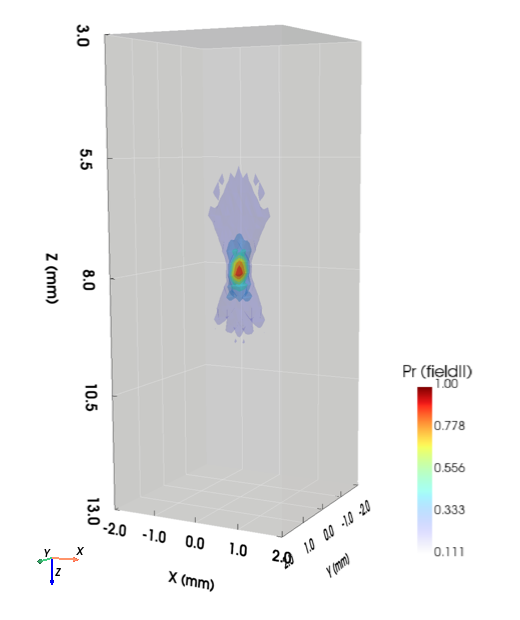

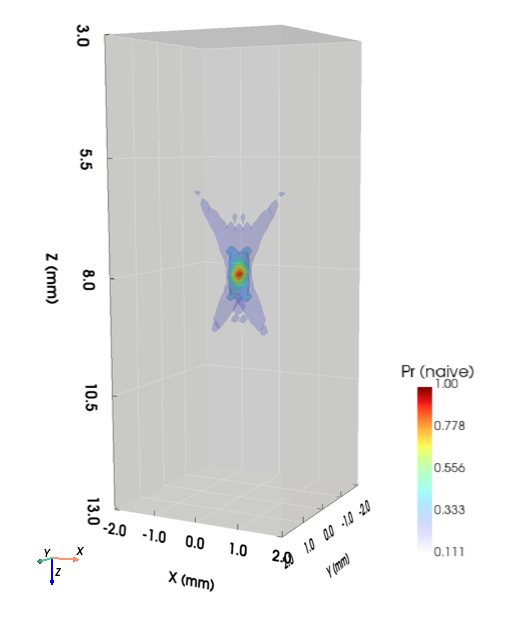

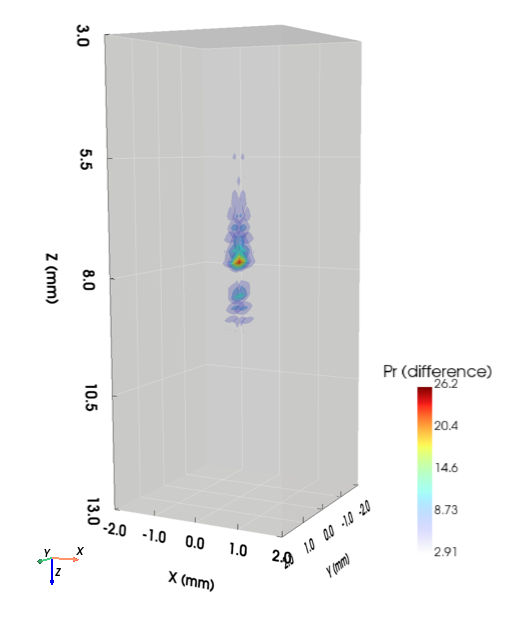

In [14]:
options_lin = {
    'window_size': (520, 620),
    'notebook': True,
    'vmin': 0,
    'ambient': 0.3,
    'scale': 1
}

diff_naive_fieldii_lin = np.abs(pr_fieldii - pr_naive)*100

camera_position = [(11.712151312469441, 22.05787209755486, 5.2576517472572855),
 (0.5030463803363143, 0.0012119780410025094, 8.759180830587963),
 (-0.06072218213806645, -0.12632568800873115, -0.9901285962669253)]

plotter = pyfield.plot_pressure_field(x_fii, y_fii, z_fii, pr_fieldii, **options_lin,
    colorbar_title='Pr (fieldII)')
plotter.camera_position = camera_position
plotter.show(jupyter_backend='static')

plotter = pyfield.plot_pressure_field(x_pf, y_pf, z_pf, pr_naive, **options_lin,
    colorbar_title='Pr (naive)')
plotter.camera_position = camera_position
plotter.show(jupyter_backend='static')

plotter = pyfield.plot_pressure_field(x_pf, y_pf, z_pf, diff_naive_fieldii_lin, **options_lin,
    colorbar_title='Pr (difference)')
plotter.camera_position = camera_position
plotter.show(jupyter_backend='static')

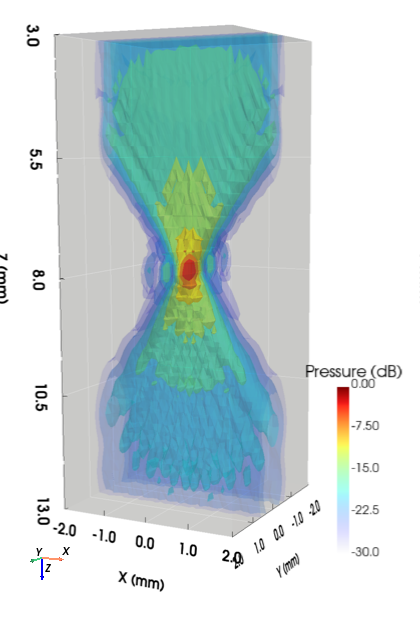

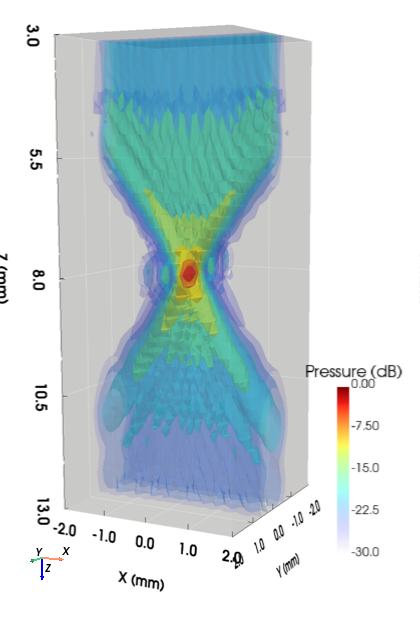

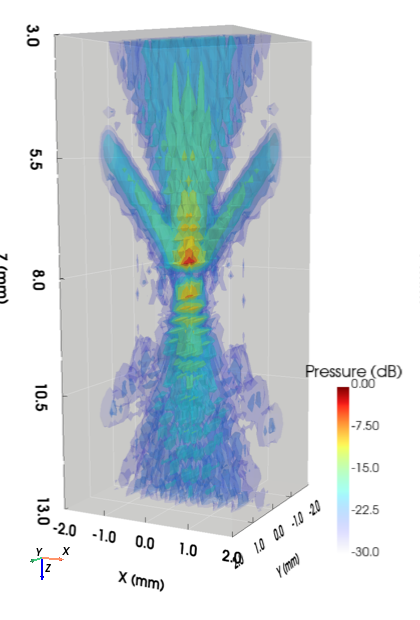

In [15]:
options_dB = {
    'window_size': (420, 620),
    'notebook': True,
    'colorbar_title': 'Pressure (dB)',
    'vmin': -30,
    'ambient': 0.3,
    'scale': 1
}

pr_naive_dB = pyfield.to_dB(pr_naive)
pr_fieldii_dB = pyfield.to_dB(pr_fieldii)
diff_naive_fieldii_dB = pyfield.to_dB(diff_naive_fieldii_lin)

plotter = pyfield.plot_pressure_field(x_fii, y_fii, z_fii, pr_fieldii_dB, **options_dB)
plotter.camera_position = camera_position
plotter.show(jupyter_backend='static')

plotter = pyfield.plot_pressure_field(x_pf, y_pf, z_pf, pr_naive_dB, **options_dB)
plotter.camera_position = camera_position
plotter.show(jupyter_backend='static')

plotter = pyfield.plot_pressure_field(x_pf, y_pf, z_pf, diff_naive_fieldii_dB, **options_dB)
plotter.camera_position = camera_position
plotter.show(jupyter_backend='static')
